# Import libraries

In [1]:
import sys
github_repo_url = "https://github.com/AnnaEls/HAADF-STEM-image-denoising.git"
!git clone {github_repo_url}
sys.path.append('/content/HAADF-STEM-image-denoising')

Cloning into 'HAADF-STEM-image-denoising'...
remote: Enumerating objects: 1286, done.
remote: Counting objects: 100% (882/882), done.
remote: Compressing objects: 100% (873/873), done.
remote: Total 1286 (delta 441), reused 0 (delta 0), pack-reused 404 (from 2)
Receiving objects: 100% (1286/1286), 104.54 MiB | 13.30 MiB/s, done.
Resolving deltas: 100% (543/543), done.
Updating files: 100% (185/185), done.


In [2]:
import os
import tifffile
import numpy as np
import matplotlib.pyplot as plt

from Utilities.Utils import convert
from Analysis.gaussian_detection import detect_and_plot_gaussian_blobs, fit_2d_gaussians, gaussian_2d
from Analysis.intensity_analysis import cluster_gaussians_by_amplitude_and_plot, build_gaussian_training_data, train_random_forest_classifier
from Analysis.intensity_analysis import classify_intensities

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.measure import profile_line


def get_linescan(image, start, end, linewidth=1, plot=True):
    """
    Extract an intensity line scan from an image.

    Parameters
    ----------
    image : 2D ndarray
        Input image.

    start : tuple
        (row, col) coordinates of the line start.

    end : tuple
        (row, col) coordinates of the line end.

    linewidth : int
        Width over which intensities are averaged.

    plot : bool
        Plot image, scan line, and intensity profile.

    Returns
    -------
    distance : ndarray
        Distance along the line in pixels.

    intensity : ndarray
        Intensity profile.
    """

    intensity = profile_line(
        image,
        start,
        end,
        linewidth=linewidth,
        reduce_func=np.mean,
        mode='reflect'
    )

    length = np.sqrt(
        (end[0] - start[0])**2 +
        (end[1] - start[1])**2
    )

    distance = np.linspace(0, length, len(intensity))

    if plot:
        fig, ax = plt.subplots(figsize=(6, 6))
        ax.imshow(image, cmap='gray')

        ax.plot(
            [start[1], end[1]],
            [start[0], end[0]],
            'r-',
            linewidth=2
        )

        ax.scatter(
            [start[1], end[1]],
            [start[0], end[0]],
            c='red'
        )

        plt.show()

        plt.figure(figsize=(8, 4))
        plt.plot(distance, intensity)
        plt.xlabel('Distance (pixels)')
        plt.ylabel('Intensity')
        plt.xlim(0, length)
        plt.ylim(0, intensity.max())
        plt.tight_layout()
        plt.show()

    return distance, intensity

# Clean image intensities classification

In [4]:
dataset_path = '/content/HAADF-STEM-image-denoising/Datasets/DATASET_MXENE/'
path_to_clean_image = dataset_path + '080kVTi3C2O2-DEMO-80kV-ground_truth_interp_0.1_dose_no_noise.tif'
clean_image = convert(tifffile.imread(path_to_clean_image))

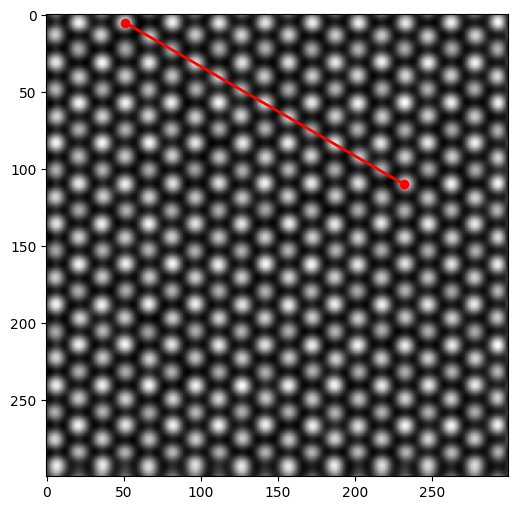

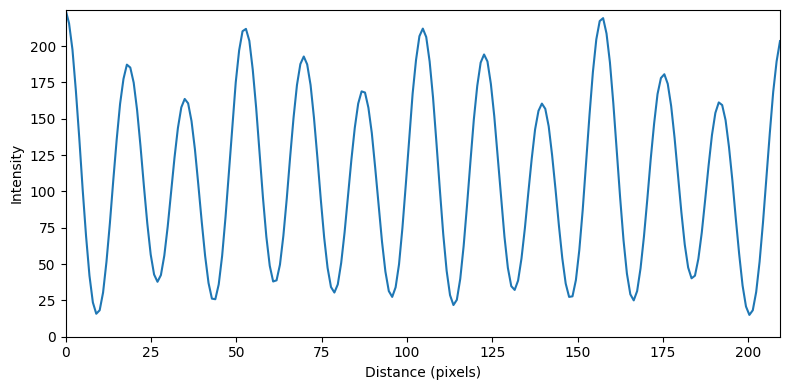

In [5]:
start = (5, 51)   # (row, column)
end   = (110, 232)

distance, intensity = get_linescan(
    clean_image,
    start,
    end,
    linewidth=5
)

Detected 340 Gaussian peaks.


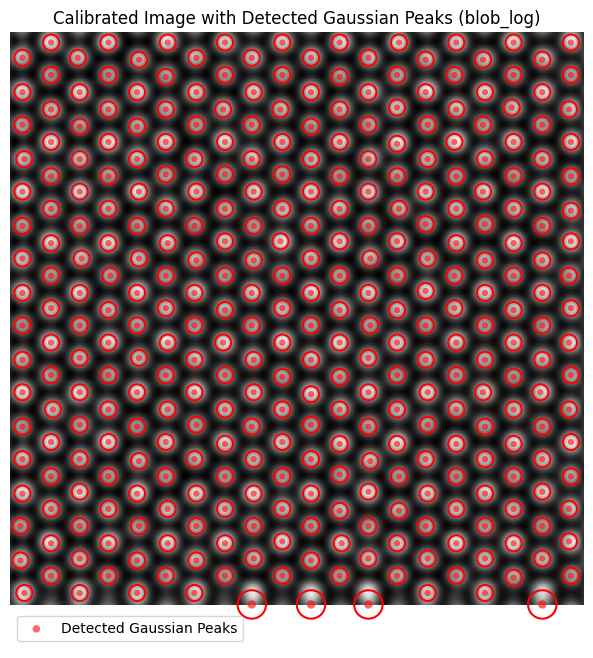

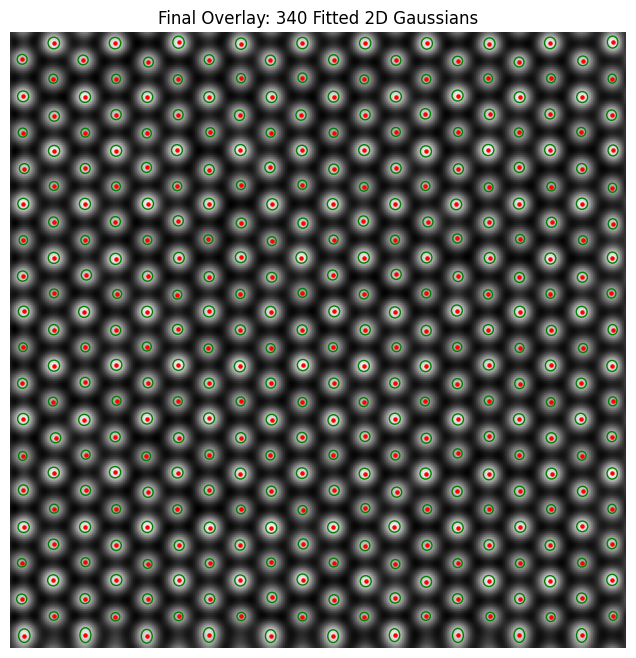

Successfully fitted and plotted 340 Gaussians.
K-Means clustering completed for 340 Gaussians.
First 10 cluster labels: [2 2 2 2 2 2 2 2 2 2]


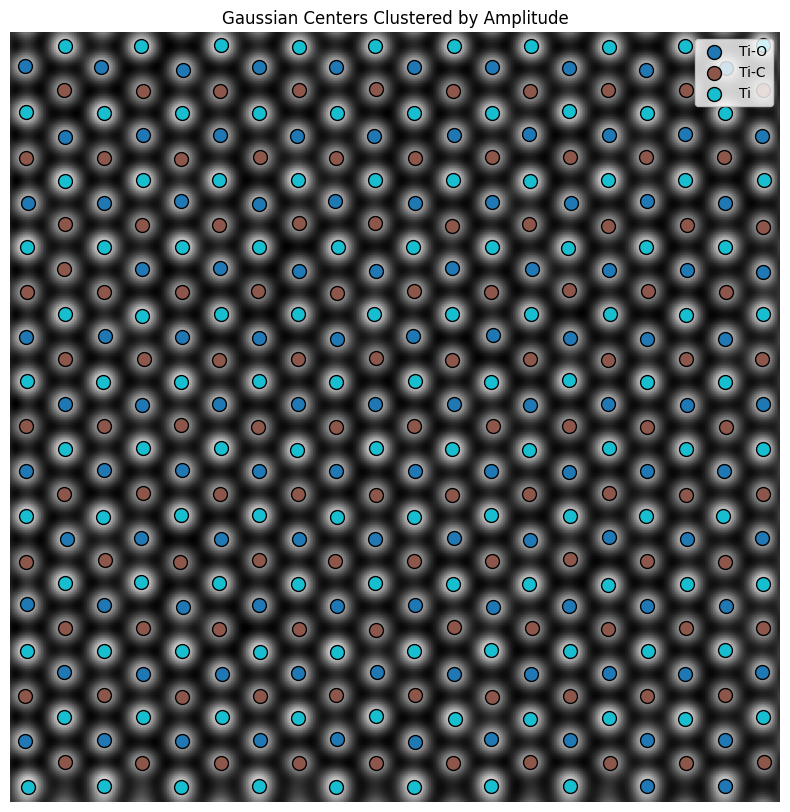

=== Random Forest Classification Metrics ===
Accuracy        : 1.0000
Precision (avg) : 1.0000
Recall (avg)    : 1.0000
F1-score (avg)  : 1.0000

Confusion Matrix:
[[22  0  0]
 [ 0 22  0]
 [ 0  0 24]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        22
           1       1.00      1.00      1.00        22
           2       1.00      1.00      1.00        24

    accuracy                           1.00        68
   macro avg       1.00      1.00      1.00        68
weighted avg       1.00      1.00      1.00        68



In [6]:
  image = clean_image
  gaussian_blobs = detect_and_plot_gaussian_blobs(image, min_sigma=1, max_sigma=30, num_sigma=10, threshold=0.2)
  gaussians = fit_2d_gaussians(image, gaussian_blobs, gaussian_2d)
  cluster_labels_clean = cluster_gaussians_by_amplitude_and_plot(image, gaussians)
  X_clean, y_clean = build_gaussian_training_data(gaussians, cluster_labels_clean[0])
  model, _ = train_random_forest_classifier(X_clean[['amplitude']], y_clean)

# Doses

In [7]:
doses = [1000000.0, 500000.0, 100000.0, 50000.0,10000.0, 5000.0, 1000.0]

# LOBATO

In [ ]:
imgs_lobato = []
results_lobato  = []
for dose in doses:
  print(f'DOSE: {dose}')
  path_to_images = f'/content/HAADF-STEM-image-denoising/Datasets/DATASET_MXENE/denoised_lobato/'
  path_to_image = path_to_images + f'080kVTi3C2O2-DEMO-080kV-jittered_interp_0.1_dose_{dose}_restored_sfr_hrstem.tif'
  image = convert(tifffile.imread(path_to_image))
  imgs_lobato.append(image)
  result, y_true, y_pred, matched_pos, mis_pos = classify_intensities(image, model, X_clean, y_clean, verbose=True)
  results_lobato.append([result, y_true, y_pred, matched_pos, mis_pos])

# PINTO

In [ ]:
imgs_pinto = []
results_pinto  = []
for dose in doses:
  path_to_images = f'/content/HAADF-STEM-image-denoising/Datasets/DATASET_MXENE/denoised_pinto/'
  path_to_image = path_to_images + f'080kVTi3C2O2-DEMO-080kV-jittered_interp_0.1_dose_{dose}_denoised_pinto.tif'
  image = convert(tifffile.imread(path_to_image))
  imgs_pinto.append(image)
  result, y_true, y_pred, matched_pos, mis_pos = classify_intensities(image, model, X_clean, y_clean, verbose=True)
  results_pinto.append([result, y_true, y_pred, matched_pos, mis_pos])

# UNIT

In [ ]:
imgs_unit = []
results_unit  = []
for dose in doses:
  path_to_images = f'/content/HAADF-STEM-image-denoising/Datasets/DATASET_MXENE/denoised_unit/'
  path_to_image = path_to_images + f'080kVTi3C2O2-DEMO-080kV-jittered_interp_0.1_dose_{dose}_unit.tif'
  image = convert(tifffile.imread(path_to_image))
  imgs_unit.append(image)
  result, y_true, y_pred, matched_pos, mis_pos = classify_intensities(image, model, X_clean, y_clean, verbose=True)
  results_unit.append([result, y_true, y_pred, matched_pos, mis_pos])

# Hybrid

Detected 339 Gaussian peaks.


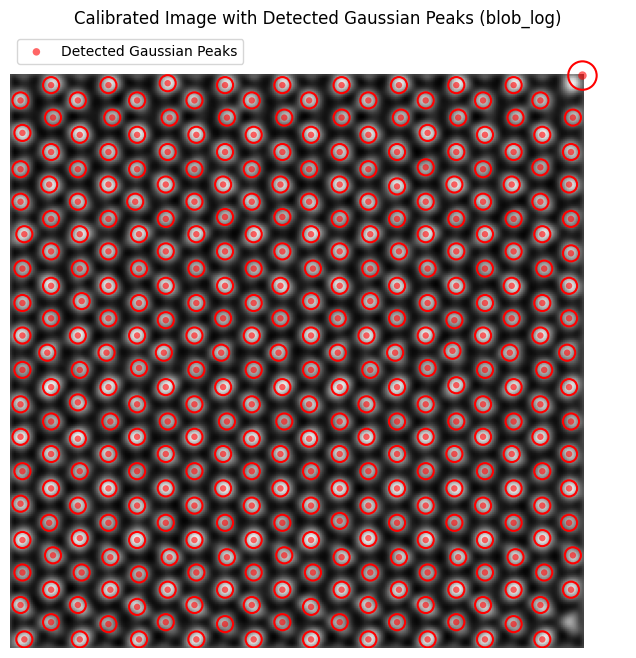

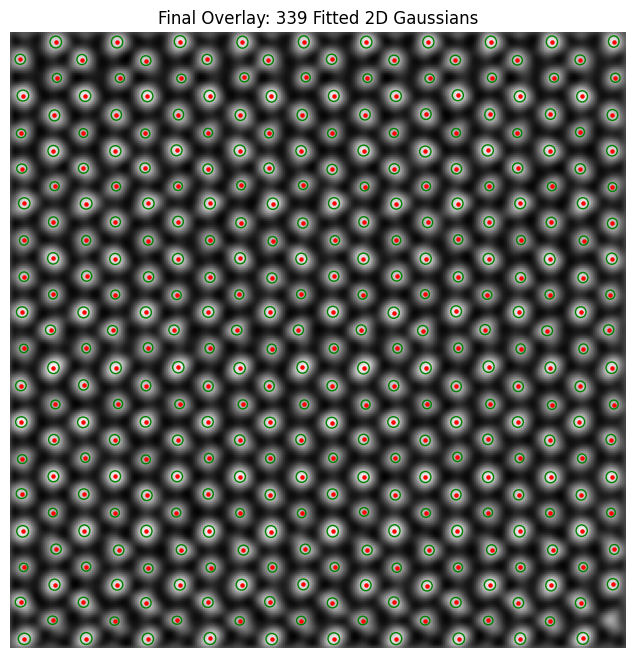

Successfully fitted and plotted 339 Gaussians.
===== METRICS ===
Total Gaussians (X_ns): 339
Matched (valid):        339
Accuracy:               0.9558

Confusion Matrix:
[[104   5   2]
 [  1 109   0]
 [  7   0 111]] 

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.94      0.93       111
           1       0.96      0.99      0.97       110
           2       0.98      0.94      0.96       118

    accuracy                           0.96       339
   macro avg       0.96      0.96      0.96       339
weighted avg       0.96      0.96      0.96       339

Misclassified points: 15


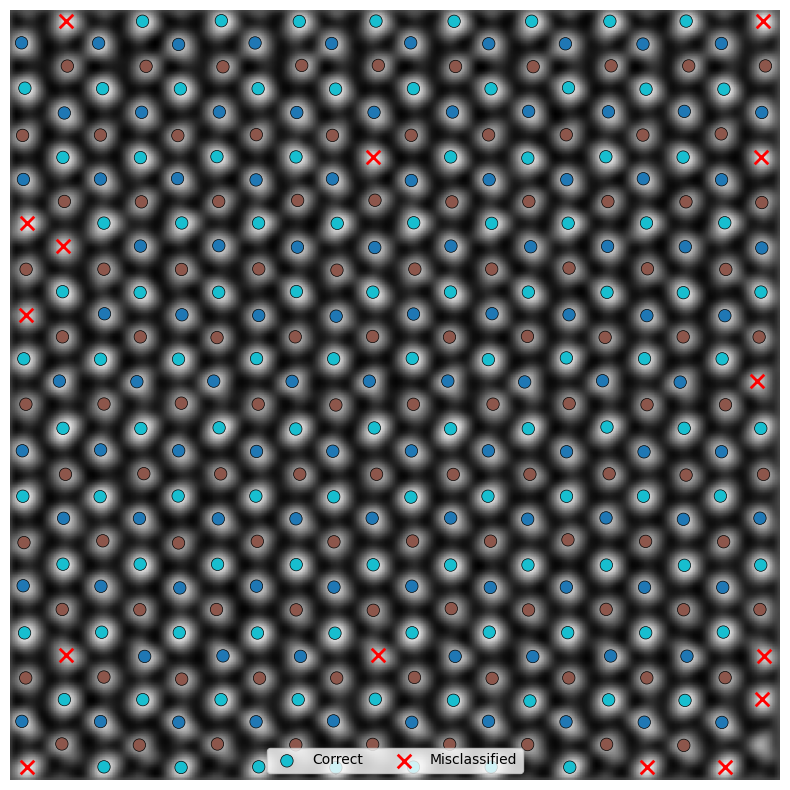

Detected 340 Gaussian peaks.


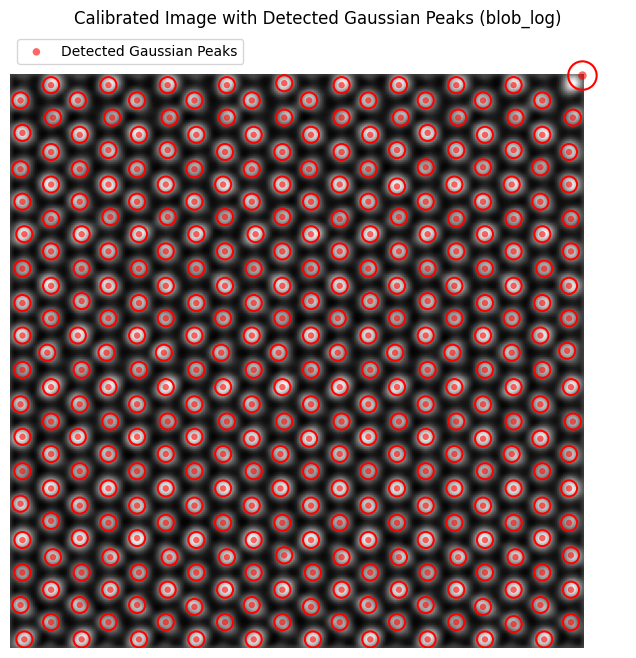

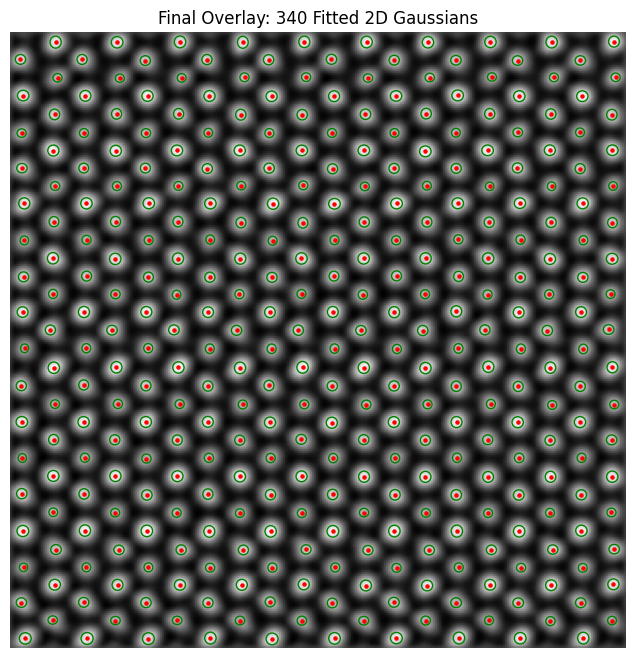

Successfully fitted and plotted 340 Gaussians.
===== METRICS ===
Total Gaussians (X_ns): 340
Matched (valid):        340
Accuracy:               0.9706

Confusion Matrix:
[[106   1   4]
 [  4 107   0]
 [  1   0 117]] 

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.95      0.95       111
           1       0.99      0.96      0.98       111
           2       0.97      0.99      0.98       118

    accuracy                           0.97       340
   macro avg       0.97      0.97      0.97       340
weighted avg       0.97      0.97      0.97       340

Misclassified points: 10


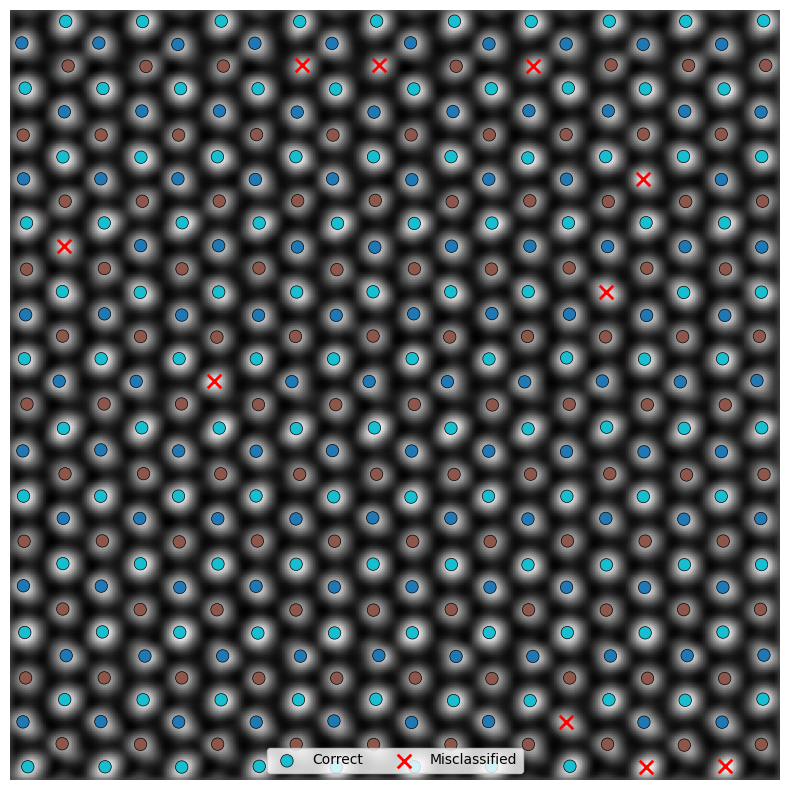

Detected 340 Gaussian peaks.


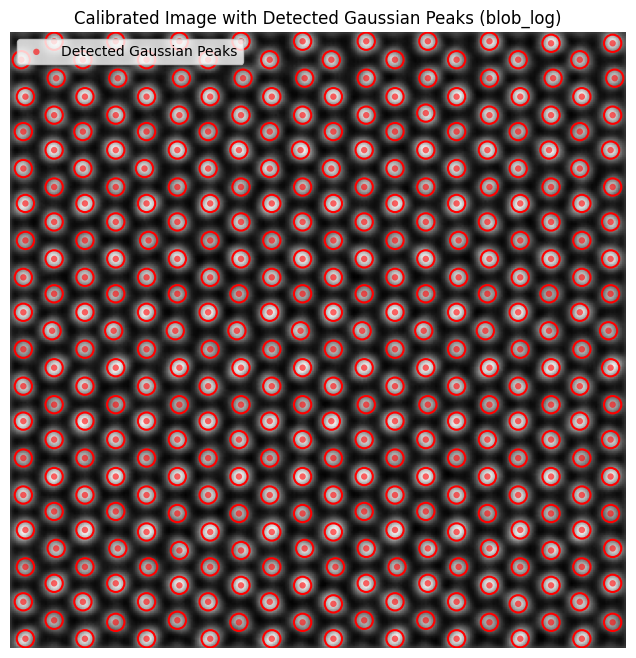

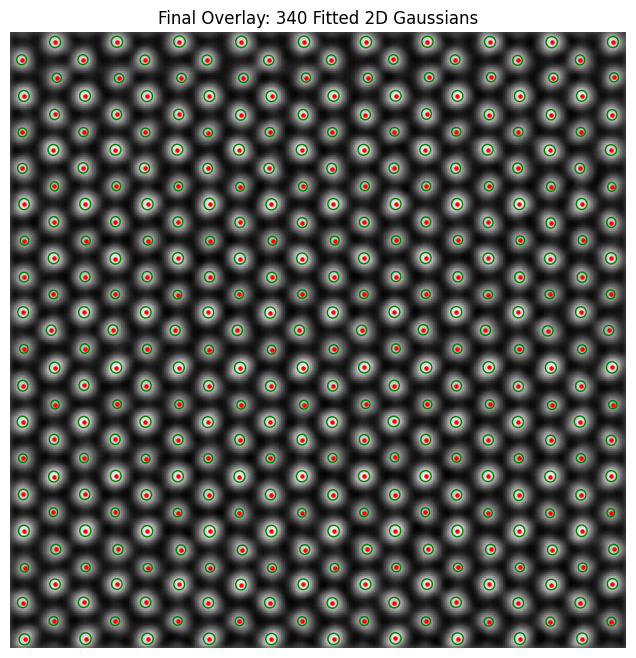

Successfully fitted and plotted 340 Gaussians.
===== METRICS ===
Total Gaussians (X_ns): 340
Matched (valid):        340
Accuracy:               0.9176

Confusion Matrix:
[[ 95   1  15]
 [ 12  99   0]
 [  0   0 118]] 

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.86      0.87       111
           1       0.99      0.89      0.94       111
           2       0.89      1.00      0.94       118

    accuracy                           0.92       340
   macro avg       0.92      0.92      0.92       340
weighted avg       0.92      0.92      0.92       340

Misclassified points: 28


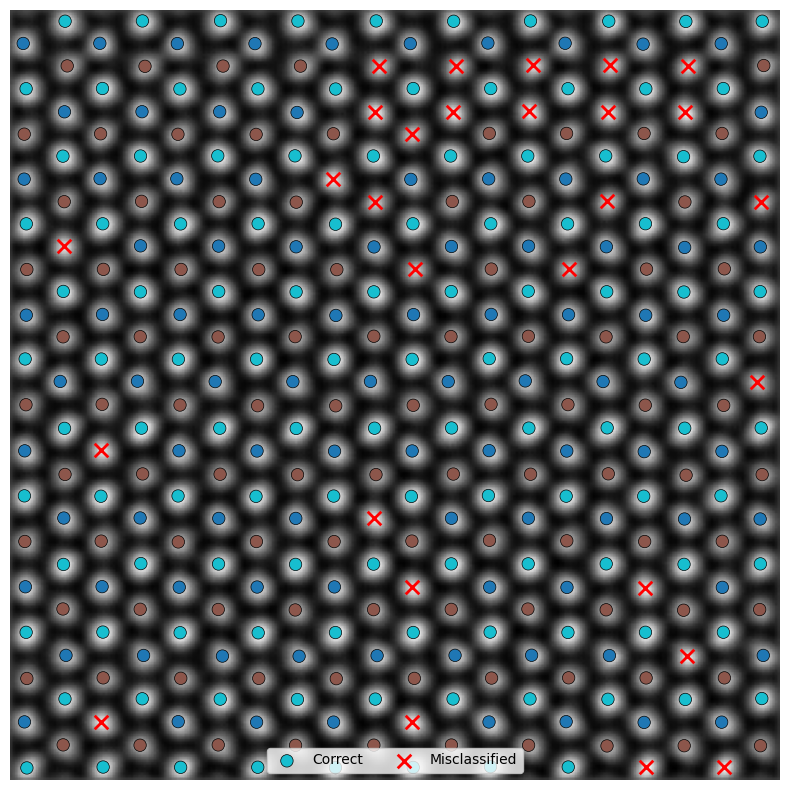

Detected 340 Gaussian peaks.


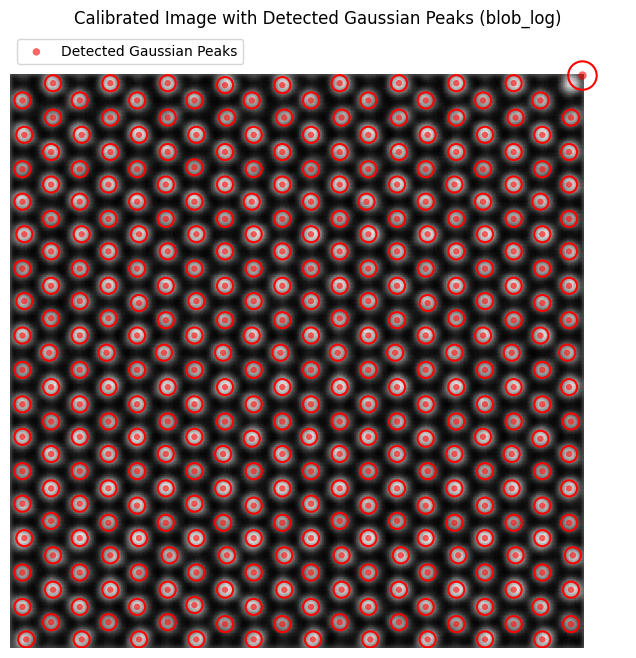

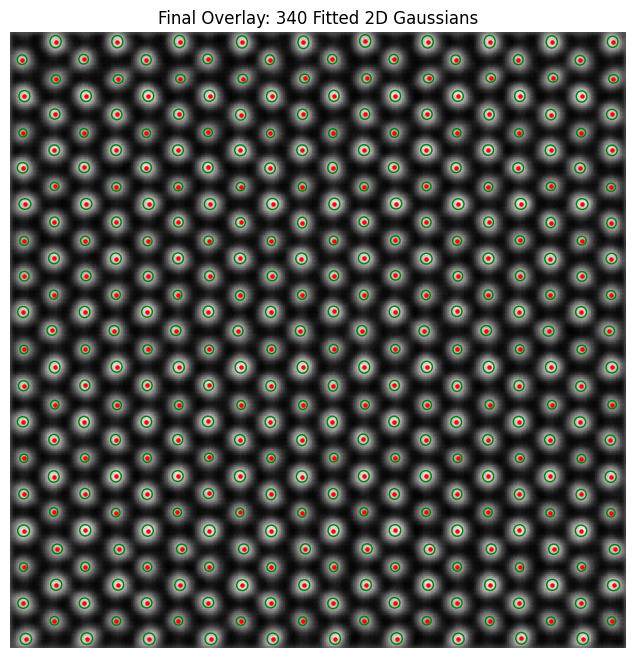

Successfully fitted and plotted 340 Gaussians.
===== METRICS ===
Total Gaussians (X_ns): 340
Matched (valid):        340
Accuracy:               0.8706

Confusion Matrix:
[[ 97   0  14]
 [ 21  90   0]
 [  9   0 109]] 

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.87      0.82       111
           1       1.00      0.81      0.90       111
           2       0.89      0.92      0.90       118

    accuracy                           0.87       340
   macro avg       0.88      0.87      0.87       340
weighted avg       0.88      0.87      0.87       340

Misclassified points: 44


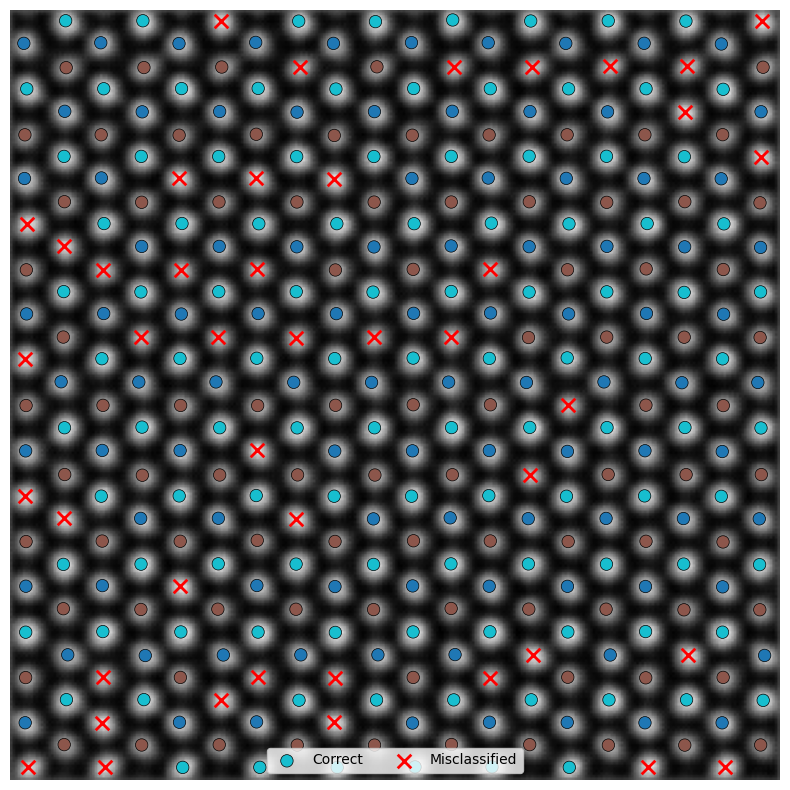

Detected 340 Gaussian peaks.


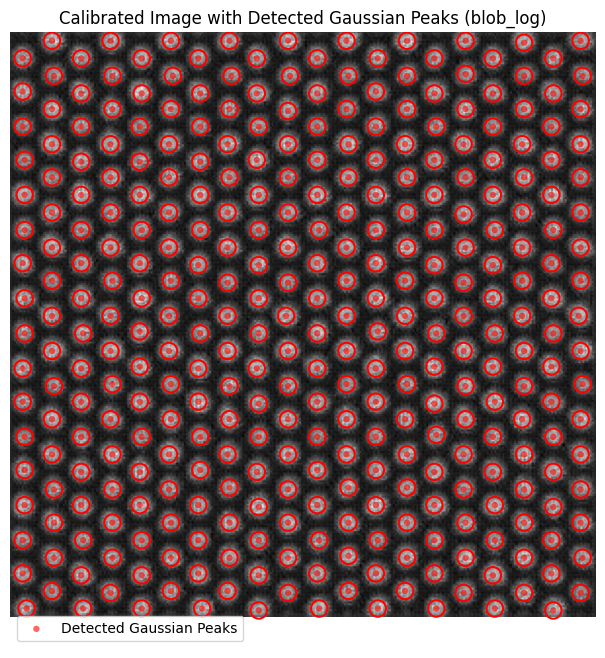

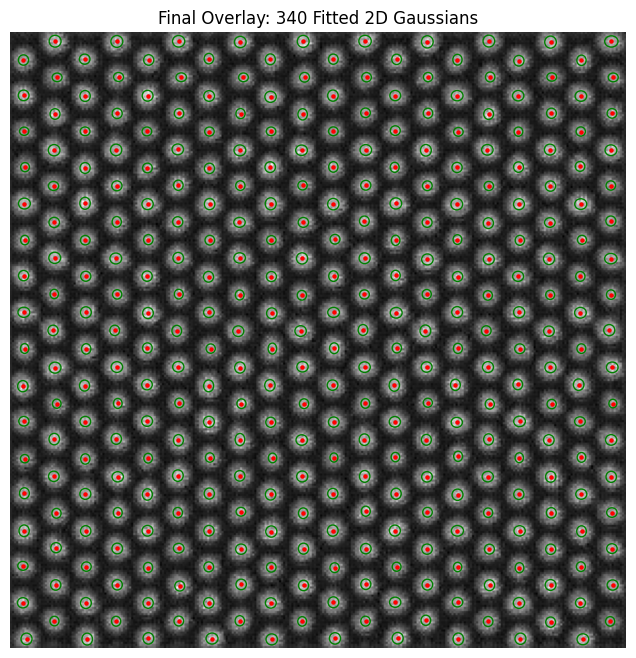

Successfully fitted and plotted 340 Gaussians.
===== METRICS ===
Total Gaussians (X_ns): 340
Matched (valid):        340
Accuracy:               0.3706

Confusion Matrix:
[[ 16  95   0]
 [  1 110   0]
 [ 54  64   0]] 

Classification Report:
              precision    recall  f1-score   support

           0       0.23      0.14      0.18       111
           1       0.41      0.99      0.58       111
           2       0.00      0.00      0.00       118

    accuracy                           0.37       340
   macro avg       0.21      0.38      0.25       340
weighted avg       0.21      0.37      0.25       340

Misclassified points: 214


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


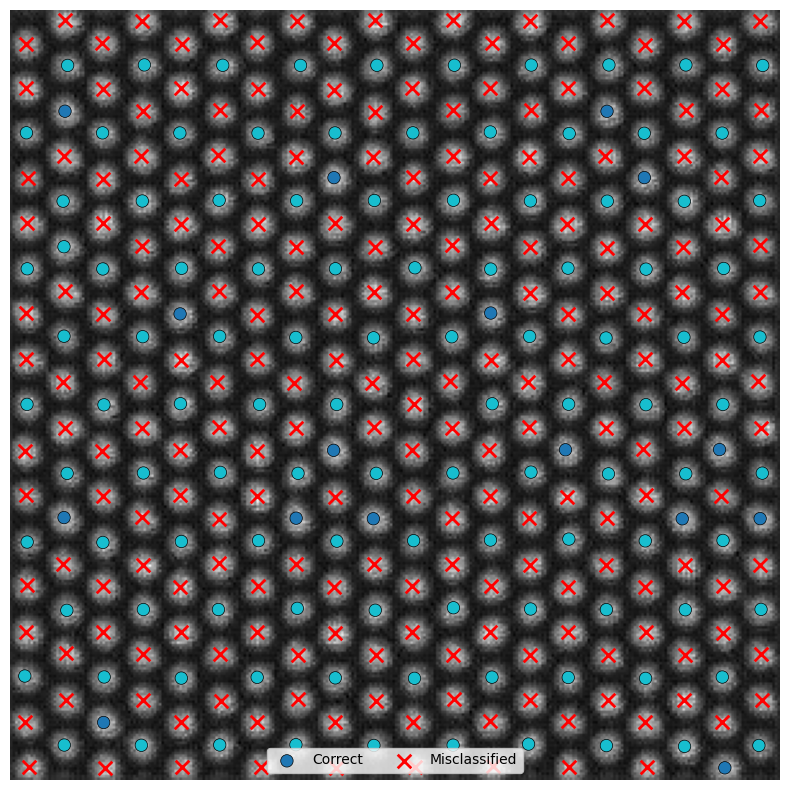

Detected 340 Gaussian peaks.


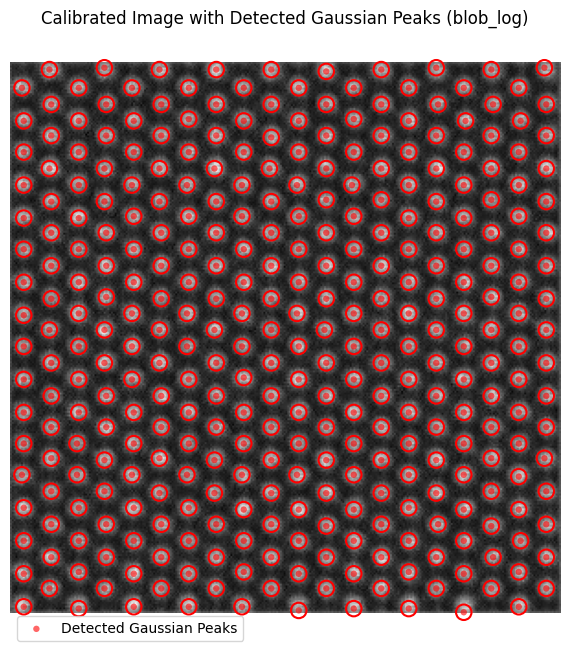

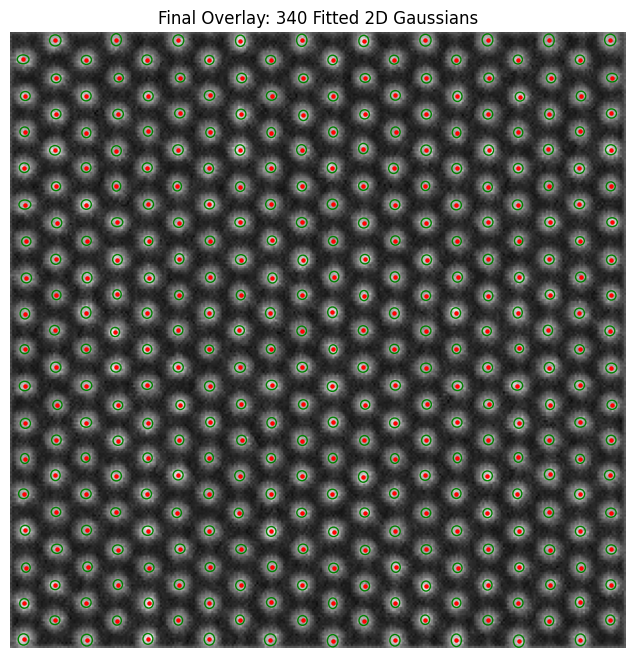

Successfully fitted and plotted 340 Gaussians.
===== METRICS ===
Total Gaussians (X_ns): 340
Matched (valid):        340
Accuracy:               0.4059

Confusion Matrix:
[[41 68  2]
 [19 92  0]
 [56 57  5]] 

Classification Report:
              precision    recall  f1-score   support

           0       0.35      0.37      0.36       111
           1       0.42      0.83      0.56       111
           2       0.71      0.04      0.08       118

    accuracy                           0.41       340
   macro avg       0.50      0.41      0.33       340
weighted avg       0.50      0.41      0.33       340

Misclassified points: 202


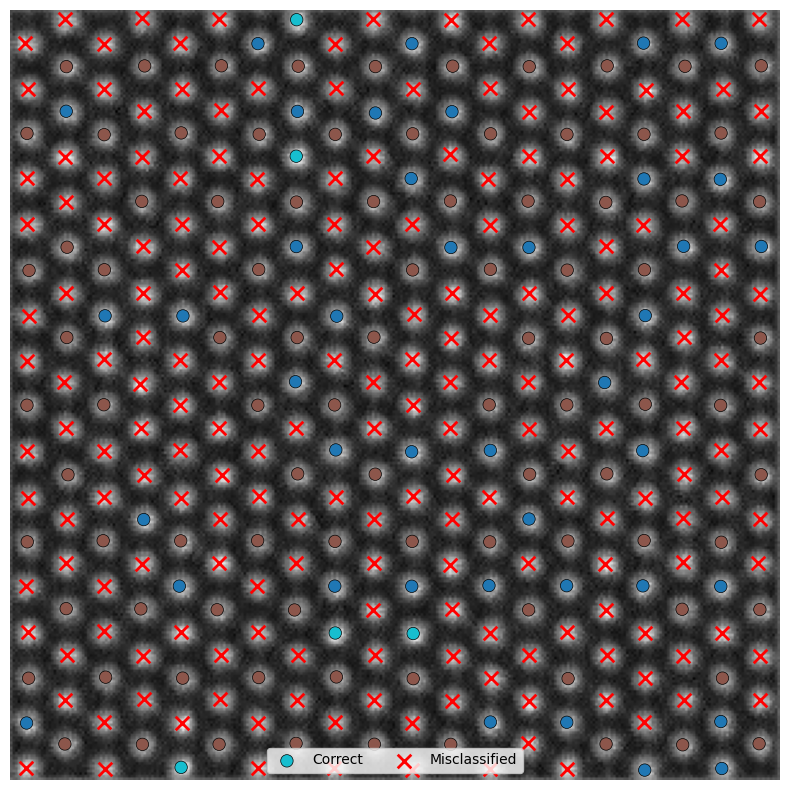

Detected 119 Gaussian peaks.


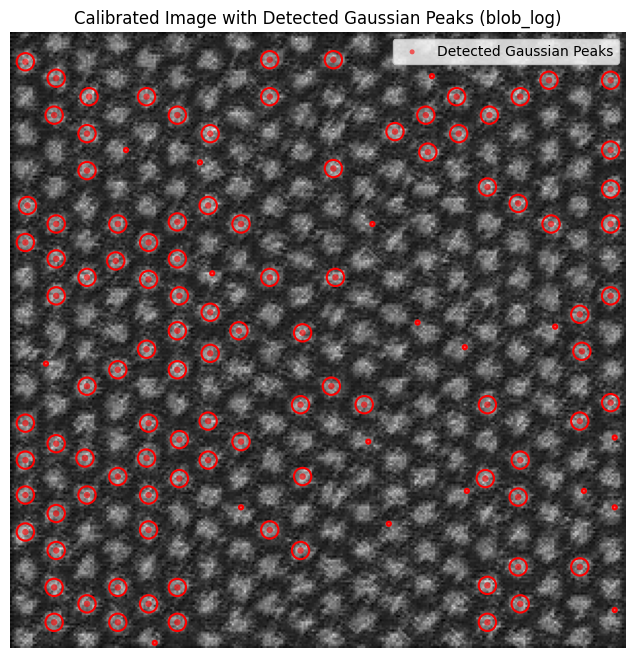

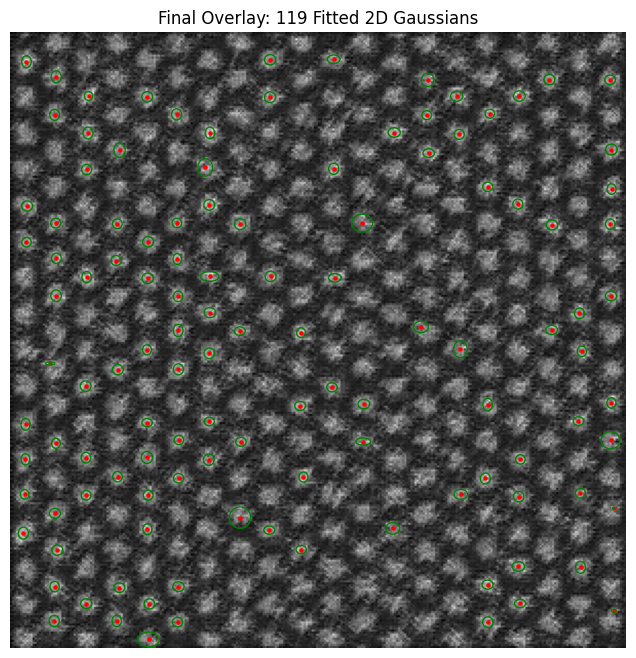

Successfully fitted and plotted 119 Gaussians.
===== METRICS ===
Total Gaussians (X_ns): 119
Matched (valid):        119
Accuracy:               0.3109

Confusion Matrix:
[[ 0 44  0]
 [ 1 37  1]
 [ 1 35  0]] 

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        44
           1       0.32      0.95      0.48        39
           2       0.00      0.00      0.00        36

    accuracy                           0.31       119
   macro avg       0.11      0.32      0.16       119
weighted avg       0.10      0.31      0.16       119

Misclassified points: 82


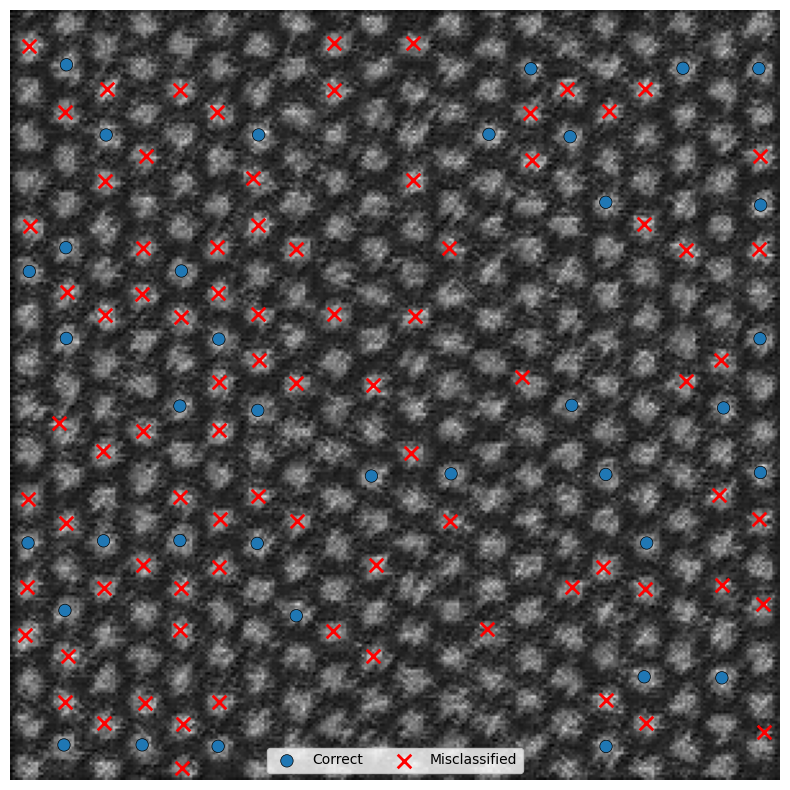

In [10]:
imgs_hybrid = []
results_hybrid   = []
for dose in doses:
  path_to_images = f'/content/HAADF-STEM-image-denoising/Datasets/DATASET_MXENE/denoised_hybrid/'
  path_to_image = path_to_images + f'080kVTi3C2O2-DEMO-080kV-jittered_interp_0.1_dose_{dose}_denoised_hybrid.tif'
  image = convert(tifffile.imread(path_to_image))
  imgs_hybrid .append(image)
  result, y_true, y_pred, matched_pos, mis_pos = classify_intensities(image, model, X_clean, y_clean, verbose=True)
  results_hybrid .append([result, y_true, y_pred, matched_pos, mis_pos])

# Noisy

In [ ]:
imgs_noisy = []
results_noisy   = []
for dose in doses:
  path_to_images = f'/content/HAADF-STEM-image-denoising/Datasets/DATASET_MXENE/'
  path_to_image = path_to_images + f'080kVTi3C2O2-DEMO-080kV-jittered_interp_0.1_dose_{dose}.tif'
  image = convert(tifffile.imread(path_to_image))
  imgs_noisy .append(image)
  result, y_true, y_pred, matched_pos, mis_pos = classify_intensities(image, model, X_clean, y_clean, verbose=True)
  results_noisy .append([result, y_true, y_pred, matched_pos, mis_pos])

# Plotting

In [13]:
def plot_classification(ax, y_true, y_pred, matched_pos, mis_pos, point_size = 80):
  mis_mask = (y_true != y_pred)
  ax.scatter(
        matched_pos[~mis_mask, 0],
        matched_pos[~mis_mask, 1],
        c=y_pred[~mis_mask],
        cmap="tab10",
        s=point_size,
        edgecolors="k",
        linewidths=0.5,
        label="Correct"
    )


  ax.scatter(
      mis_pos[:, 0],
      mis_pos[:, 1],
      marker="x",
      c="red",
      s=point_size * 1.2,
      linewidths=2,
      label="Misclassified"
  )

In [16]:
k = 3
images = [imgs_noisy[k], imgs_hybrid[k], imgs_lobato[k], imgs_pinto[k], imgs_unit[k]]
y_true = [results_noisy[k][1], results_hybrid[k][1], results_lobato[k][1], results_pinto[k][1],results_unit[k][1]]
y_pred = [results_noisy[k][2], results_hybrid[k][2], results_lobato[k][2], results_pinto[k][2],results_unit[k][2]]
matched_pos = [results_noisy[k][3], results_hybrid[k][3], results_lobato[k][3], results_pinto[k][3],results_unit[k][3]]
mis_pos = [results_noisy[k][4], results_hybrid[k][4], results_lobato[k][4], results_pinto[k][4],results_unit[k][4]]

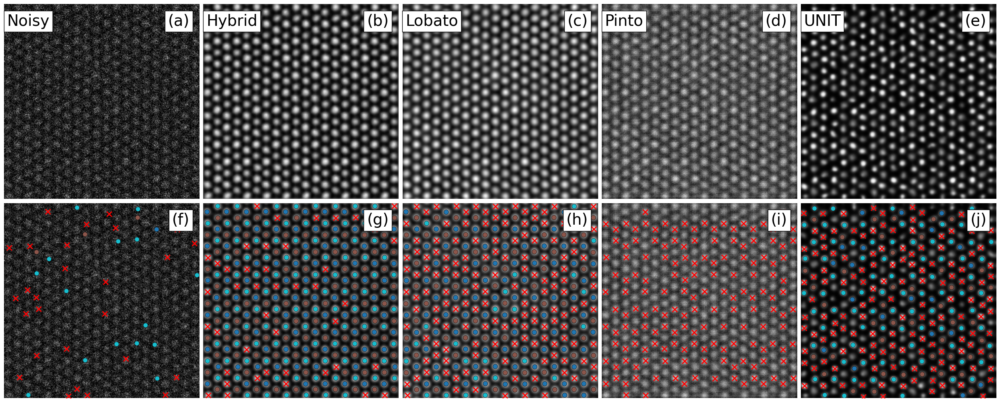

In [17]:
n = len(images)
sub = 2
models = ["Noisy", "Hybrid", "Lobato", "Pinto", "UNIT"]
letters_img = ["(a)", "(b)", "(c)", "(d)", "(e)"]
letters_imgs_c = ["(f)", "(g)", "(h)", "(i)", "(j)"]

fig = plt.figure(
    figsize=(5*n, 5*sub),
    constrained_layout=True
)

gs = fig.add_gridspec(sub, n )

plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 22
})
for idx, image in enumerate(images):
  ax_img = fig.add_subplot(gs[0, idx])
  ax_img.imshow(image, cmap='gray')
  ax_img.axis('off')

  ax_img.text(0.015, 0.95, models[idx],
            transform=ax_img.transAxes,
            fontsize=28,
            va='top',
            ha='left',
            bbox=dict(facecolor='white', edgecolor='black', boxstyle='square,pad=0.2'))

  ax_img.text(0.95, 0.95, letters_img[idx],
            transform=ax_img.transAxes,
            fontsize=28,
            va='top',
            ha='right',
            bbox=dict(facecolor='white', edgecolor='black', boxstyle='square,pad=0.2'))

  ax_img = fig.add_subplot(gs[1, idx])
  ax_img.imshow(image, cmap='gray')
  plot_classification(ax_img, y_true[idx], y_pred[idx], matched_pos[idx], mis_pos[idx], point_size = 70)
  ax_img.axis('off')

  ax_img.text(0.95, 0.95, letters_imgs_c[idx],
            transform=ax_img.transAxes,
            fontsize=28,
            va='top',
            ha='right',
            bbox=dict(facecolor='white', edgecolor='black', boxstyle='square,pad=0.2'))




